# Prompt Importance

**Feeds:** RQ1 (prompt sensitivity, PT vs EN). This notebook also produces the
two selection artifacts that notebooks 02-04 depend on -- **run this notebook
first**:

- `best_templates.json` -- the best prompt template per (model, language),
  chosen on the prompt-selection stage;
- `best_configs.json` -- the best *(template, temperature)* configuration per
  (model, language), chosen among the test-stage runs that carry that
  template. This is what notebooks 02-04 actually filter on, because a
  test-stage run is identified by template *and* decoding temperature.

Uses `results/prompt_selection/{portuguese,english}/results.csv`: 8 prompt
templates (`cls`, `cls_def`, `cls_def_exp`, `cls_exp`, `ext`, `ext_def`,
`ext_def_exp`, `ext_exp`) x up to 5 models, evaluated on the 20
prompt-selection documents.

In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
# Canonical prompt-variation order lives in _common.py so every figure that
# ranges over the eight variations uses the same left-to-right order.
BASE_TEMPLATES = c.PROMPT_VAR_ORDER

results = pd.concat([c.load_results("prompt_selection", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
results = results[results["template"].isin(BASE_TEMPLATES) & (results["model"] != "llama32_3b")].reset_index(drop=True)
results.head(55)

,model,template,entity,precision,recall,f1,f1_r_micro,f1_r_macro,f1_r,stage,language
0,amalia,ext,participants,0.000000,0.000000,0.000000,0.016791,0.013566,0.013566,prompt_selection,portuguese
1,amalia,ext_def,participants,0.166667,0.001912,0.003781,0.009452,0.006925,0.006925,prompt_selection,portuguese
2,amalia,ext_exp,participants,0.188679,0.019120,0.034722,0.074653,0.042881,0.042881,prompt_selection,portuguese
3,amalia,cls_def,participants,0.180556,0.024857,0.043697,0.129412,0.099716,0.099716,prompt_selection,portuguese
4,amalia,ext_def_exp,participants,0.070946,0.040153,0.051282,0.129426,0.094790,0.094790,prompt_selection,portuguese
5,amalia,cls,participants,0.244186,0.040153,0.068966,0.144499,0.130103,0.130103,prompt_selection,portuguese
6,amalia,cls_exp,participants,0.148649,0.084130,0.107448,0.218559,0.203377,0.203377,prompt_selection,portuguese
7,amalia,cls_def_exp,participants,0.225581,0.185468,0.203568,0.349423,0.328473,0.328473,prompt_selection,portuguese
8,euro_llm_9b,cls,participants,0.263889,0.036329,0.063866,0.122689,0.088558,0.088558,prompt_selection,portuguese
9,euro_llm_9b,cls_def,participants,0.256410,0.038241,0.066556,0.149750,0.117259,0.117259,prompt_selection,portuguese


## Combined view: Precision/Recall/F1 distribution per template

Pooling across models and entities (the `results` frame, already restricted to
`BASE_TEMPLATES`) into one boxplot per template isolates the template effect:
it shows whether a template (e.g. the `*_exp` family) is consistently better,
rather than better for just one model. Kept split by language, since PT vs EN
prompt sensitivity is part of RQ1.

C:\Users\davib\AppData\Local\Temp\ipykernel_10660\3620180845.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")


C:\Users\davib\AppData\Local\Temp\ipykernel_10660\3620180845.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_combined_boxplot_by_template_language.pdf


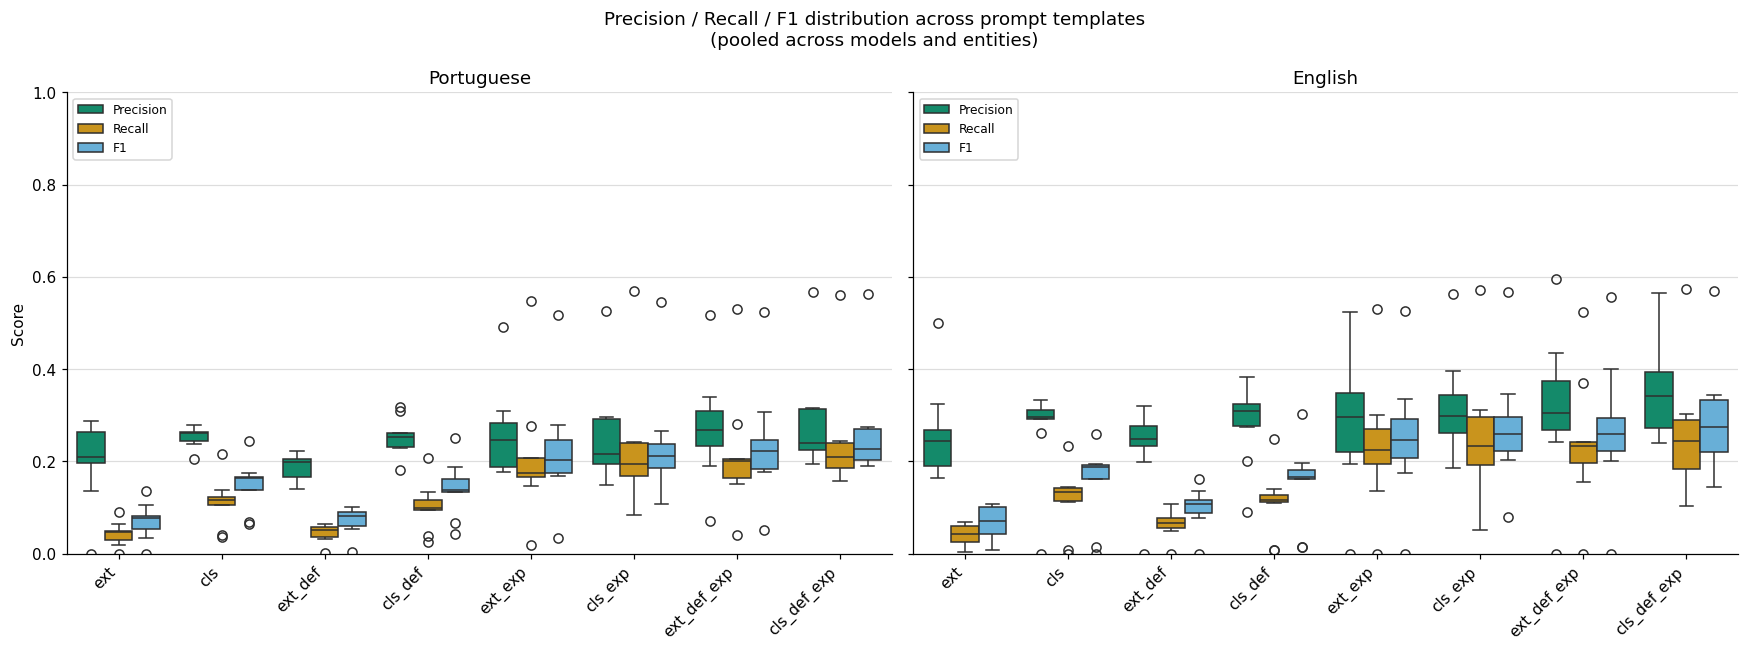

In [3]:
METRIC_ORDER = ["precision", "recall", "f1"]
METRIC_LABELS = {"precision": "Precision", "recall": "Recall", "f1": "F1"}
METRIC_COLORS = {"precision": "#009E73", "recall": "#E69F00", "f1": "#56B4E9"}

metric_long = results.melt(
    id_vars=["template", "language"],
    value_vars=METRIC_ORDER,
    var_name="metric",
    value_name="score",
)
metric_long["metric"] = metric_long["metric"].map(METRIC_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = metric_long[metric_long["language"] == lang]
    sns.boxplot(
        data=sub,
        x="template",
        y="score",
        hue="metric",
        order=BASE_TEMPLATES,
        hue_order=[METRIC_LABELS[m] for m in METRIC_ORDER],
        palette={METRIC_LABELS[m]: METRIC_COLORS[m] for m in METRIC_ORDER},
        ax=ax,
    )
    ax.set_xticklabels(BASE_TEMPLATES, rotation=45, ha="right")
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title=None, loc="upper left", fontsize=8)
    c.style_axis(ax)
fig.suptitle("Precision / Recall / F1 distribution across prompt templates\n(pooled across models and entities)")
c.save_fig(fig, "01_combined_boxplot_by_template_language")
plt.show()


### Best F1 template per model

The bar chart above suggests the `*_exp` templates dominate, but that's hard
to read off 8 clustered bars per model. A heatmap of F1 by (model, template),
with the templates ordered so each successive pair adds one prompt component
(bare, `+def`, `+exp`, `+def+exp`), makes the pattern explicit.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_best_template_heatmap.pdf


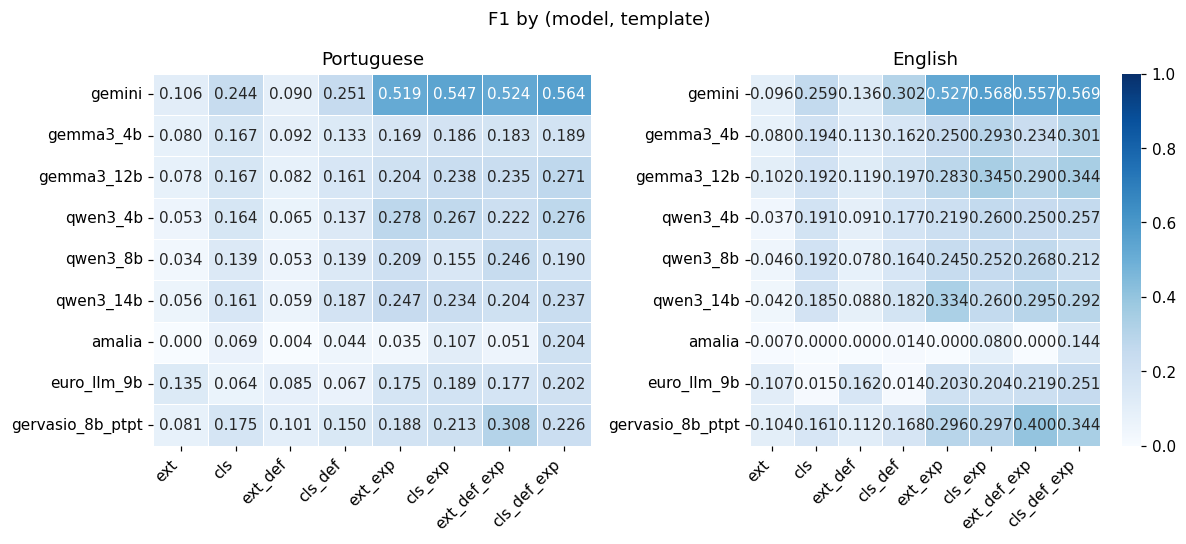

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for i, (ax, lang) in enumerate(zip(axes, c.LANGUAGE_ORDER)):
    sub = results[results["language"] == lang]
    pivot = sub.pivot(index="model", columns="template", values="f1").reindex(index=c.MODEL_ORDER, columns=BASE_TEMPLATES)
    sns.heatmap(
        pivot, ax=ax, cmap=c.HEATMAP_CMAP, vmin=0, vmax=1, annot=True, fmt=".3f",
        cbar=(i == len(c.LANGUAGE_ORDER) - 1), linewidths=0.5, linecolor="white",
    )
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("F1 by (model, template)")
c.save_fig(fig, "01_best_template_heatmap")
plt.show()

## Prompt sensitivity: dispersion of F1 across templates

In [5]:
disp = (
    results.groupby(["language", "model"])["f1"]
    .agg(std="std", min="min", max="max")
    .assign(range=lambda d: d["max"] - d["min"])
    .reset_index()
)
disp


,language,model,std,min,max,range
0,english,amalia,0.053256,0.000000,0.144168,0.144168
1,english,euro_llm_9b,0.092007,0.014467,0.250569,0.236103
2,english,gemini,0.201827,0.095532,0.569302,0.473771
3,english,gemma3_12b,0.095599,0.101949,0.345339,0.243390
4,english,gemma3_4b,0.080755,0.080477,0.300804,0.220327
5,english,gervasio_8b_ptpt,0.112567,0.103937,0.399594,0.295657
6,english,qwen25_14b,0.053472,0.062914,0.213018,0.150104
7,english,qwen3_14b,0.104332,0.042484,0.334463,0.291980
8,english,qwen3_4b,0.081958,0.037037,0.259835,0.222798
9,english,qwen3_8b,0.081713,0.046129,0.267682,0.221554


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_prompt_sensitivity_dispersion.pdf


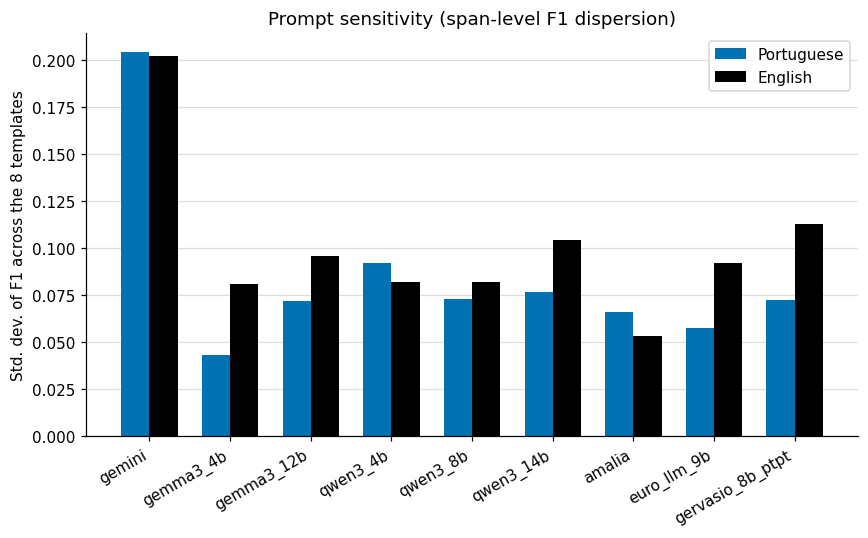

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(c.MODEL_ORDER))
width = 0.35
for i, lang in enumerate(c.LANGUAGE_ORDER):
    sub = disp[disp["language"] == lang].set_index("model").reindex(c.MODEL_ORDER)
    ax.bar(x + (i - 0.5) * width, sub["std"].values, width=width, color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(c.MODEL_ORDER, rotation=30, ha="right")
ax.set_ylabel("Std. dev. of F1 across the 8 templates")
ax.set_title("Prompt sensitivity (span-level F1 dispersion)")
ax.legend()
c.style_axis(ax)
c.save_fig(fig, "01_prompt_sensitivity_dispersion")
plt.show()


### F1 spread per model, both languages

The bar chart above reduces each model's prompt sensitivity to a single number.
This shows the distribution behind it: one box per (model, language) over the
8 prompt templates (n = 8 per box), so the median level and the spread are
readable together. Model order matches the heatmap, and the F1 axis is kept on
the full 0-1 range so this can be read directly against the heatmap and the
combined boxplot rather than on its own rescaled axis.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_f1_distribution_by_model_language.pdf


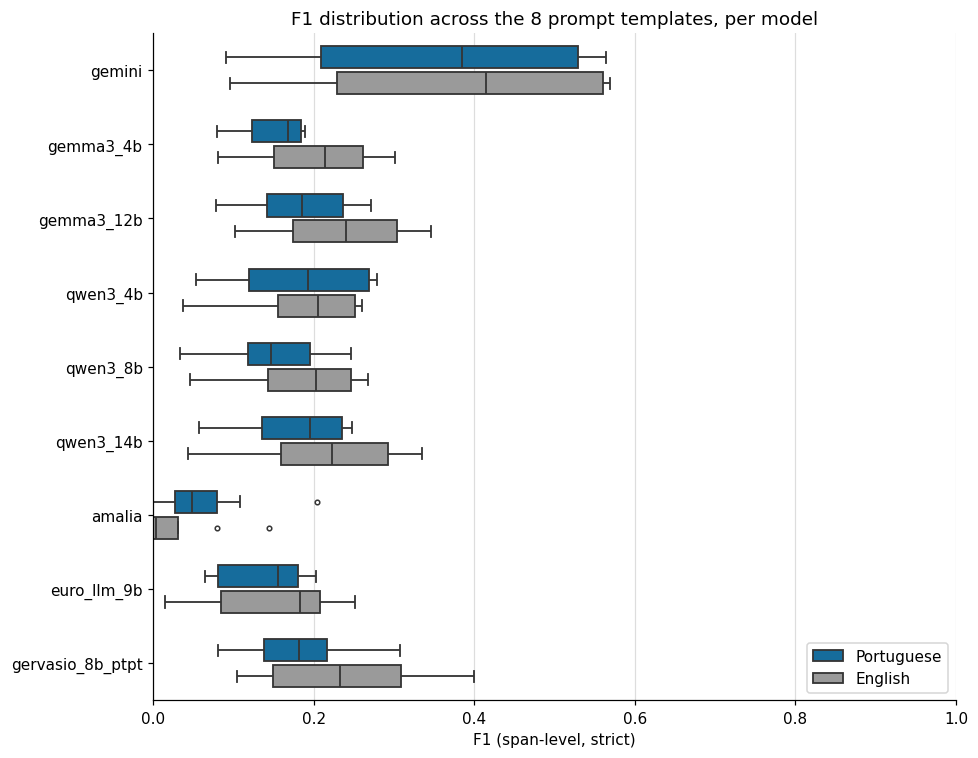

In [7]:
# Portuguese filled blue, English filled grey. Defined locally rather than in
# c.LANGUAGE_COLORS, which the other figures in this notebook still use.
BOX_LANGUAGE_COLORS = {"portuguese": "#0072B2", "english": "#9A9A9A"}

fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(
    data=results, x="f1", y="model", hue="language",
    order=c.MODEL_ORDER, hue_order=c.LANGUAGE_ORDER,
    palette=BOX_LANGUAGE_COLORS, fill=True, gap=0.15, width=0.7,
    linewidth=1.2, fliersize=3, ax=ax,
)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 (span-level, strict)")
ax.set_ylabel("")
ax.set_title("F1 distribution across the 8 prompt templates, per model")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [l.capitalize() for l in labels], title=None, loc="lower right")
c.style_axis(ax)
# style_axis grids the y axis, which is categorical here -- the useful
# reference lines run along the F1 axis instead.
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
c.save_fig(fig, "01_f1_distribution_by_model_language")
plt.show()

## Determining the best template per (model, language)

Best template = argmax F1 only (no F1-r tie-break), for consistency with
the F1 heatmap above. Exported to `best_templates.json`; the temperature is
added to it further down, in "Selecting the best (template, temperature)
configuration".

In [8]:
best_rows = results.sort_values("f1", ascending=False).drop_duplicates(subset=["language", "model"], keep="first")

best_templates = {}
for lang in c.LANGUAGE_ORDER:
    lang_rows = best_rows[best_rows["language"] == lang]
    best_templates[lang] = dict(zip(lang_rows["model"], lang_rows["template"]))

best_templates

{'portuguese': {'gemini': 'cls_def_exp',
  'gervasio_8b_ptpt': 'ext_def_exp',
  'qwen3_4b': 'ext_exp',
  'gemma3_12b': 'cls_def_exp',
  'qwen3_14b': 'ext_exp',
  'qwen3_8b': 'ext_def_exp',
  'amalia': 'cls_def_exp',
  'euro_llm_9b': 'cls_def_exp',
  'gemma3_4b': 'cls_def_exp'},
 'english': {'gemini': 'cls_def_exp',
  'gervasio_8b_ptpt': 'ext_def_exp',
  'gemma3_12b': 'cls_exp',
  'qwen3_14b': 'ext_exp',
  'gemma3_4b': 'cls_def_exp',
  'qwen3_8b': 'ext_def_exp',
  'qwen3_4b': 'cls_exp',
  'euro_llm_9b': 'cls_def_exp',
  'qwen25_14b': 'cls_exp',
  'amalia': 'cls_def_exp'}}

In [9]:
path = c.save_best_templates(best_templates)
print(f"Saved best templates to {path}")


Saved best templates to C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\notebooks\results\best_templates.json


## Supplementary: temperature sensitivity in the test stage (PT and EN)

Scope of this subsection: the **test** stage only, in **both languages**. Each
model was run in the test stage on its own base template (the one selected
above), swept over decoding temperature (0.3/0.6/1.0).

Test-stage run names encode the full decoding configuration as
`<template>_temp<T>_<delim>_<role>_<cot>`. For this analysis only the
**template and the temperature** matter, so everything after the temperature
is dropped (`_common.add_run_config_columns`) and the runs that differ only in
those trailing fields are averaged into a single (template, temperature)
point. Runs whose name carries no `temp` suffix predate the sweep and used the
pipeline default temperature of 0.3 (`experiments/test.py`), so they are folded
into the 0.3 group -- this affects PT/`gemini` only, whose T=0.3 point is the
mean of its pre-sweep and swept runs.

Every model shown has the full 0.3/0.6/1.0 sweep in both languages.
`amalia` is excluded from the figure: it is served through an API that does
not expose the decoding temperature, so it has a single recorded point and no
within-model temperature sensitivity can be read off it.

In [10]:
def load_temperature_ablation(language: str) -> pd.DataFrame:
    """Test-stage results for `language`, reduced to (model, template, temperature).

    Everything in the run name after the temperature (delim/role/CoT) is
    dropped and averaged over, since it is out of scope here. Runs with no
    `temp` suffix predate the sweep and are folded into the pipeline default
    (`c.TEST_DEFAULT_TEMPERATURE`) by `c.add_run_config_columns`.
    """
    df = c.add_run_config_columns(c.load_results("test", language))
    out = df.groupby(["model", "base_template", "temperature"], as_index=False)[["f1", "f1_r"]].mean()
    out["config"] = out["base_template"] + "\nT = " + out["temperature"].map("{:.1f}".format)
    out["language"] = language
    return out


ablation = pd.concat([load_temperature_ablation(lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
ablation.sort_values(["language", "model", "temperature"]).reset_index(drop=True)

,model,base_template,temperature,f1,f1_r,config,language
0,amalia,cls_def_exp,0.3,0.105235,0.147683,cls_def_exp\nT = 0.3,english
1,euro_llm_9b,cls_exp,0.3,0.213067,0.373824,cls_exp\nT = 0.3,english
2,euro_llm_9b,cls_exp,0.6,0.218257,0.375175,cls_exp\nT = 0.6,english
3,euro_llm_9b,cls_exp,1.0,0.164318,0.290133,cls_exp\nT = 1.0,english
4,gemini,ext_def_exp,0.3,0.522479,0.646816,ext_def_exp\nT = 0.3,english
5,gemini,ext_def_exp,0.6,0.523115,0.648216,ext_def_exp\nT = 0.6,english
6,gemini,ext_def_exp,1.0,0.521900,0.647340,ext_def_exp\nT = 1.0,english
7,gemma3_12b,cls_exp,0.3,0.350959,0.529031,cls_exp\nT = 0.3,english
8,gemma3_12b,cls_exp,0.6,0.369510,0.543279,cls_exp\nT = 0.6,english
9,gemma3_12b,cls_exp,1.0,0.365303,0.541151,cls_exp\nT = 1.0,english


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_temperature_ablation_portuguese.pdf


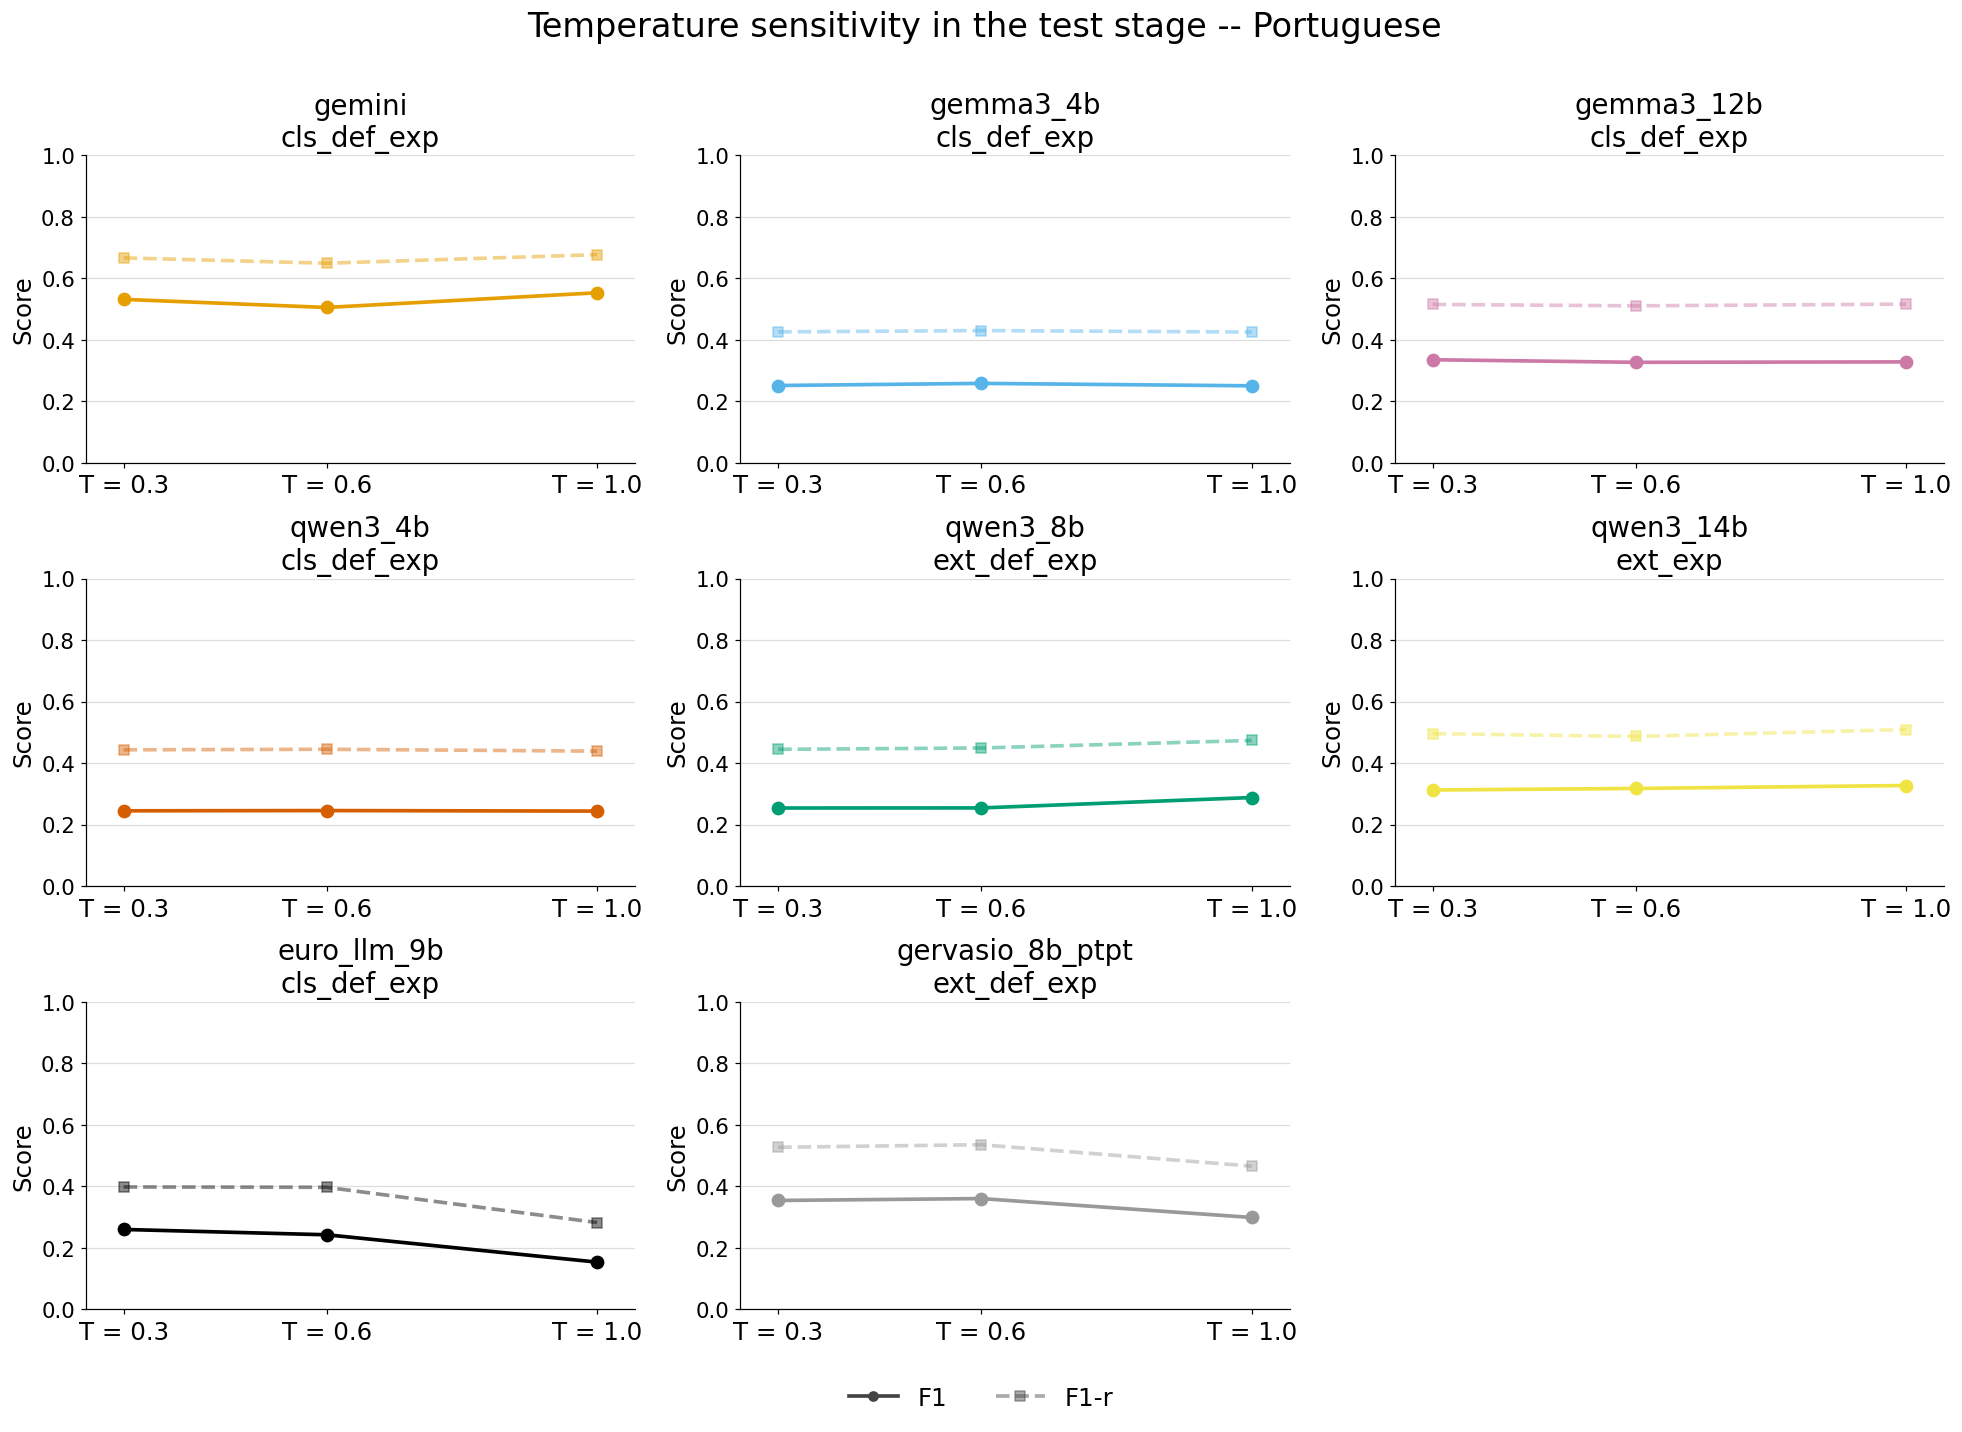

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_temperature_ablation_english.pdf


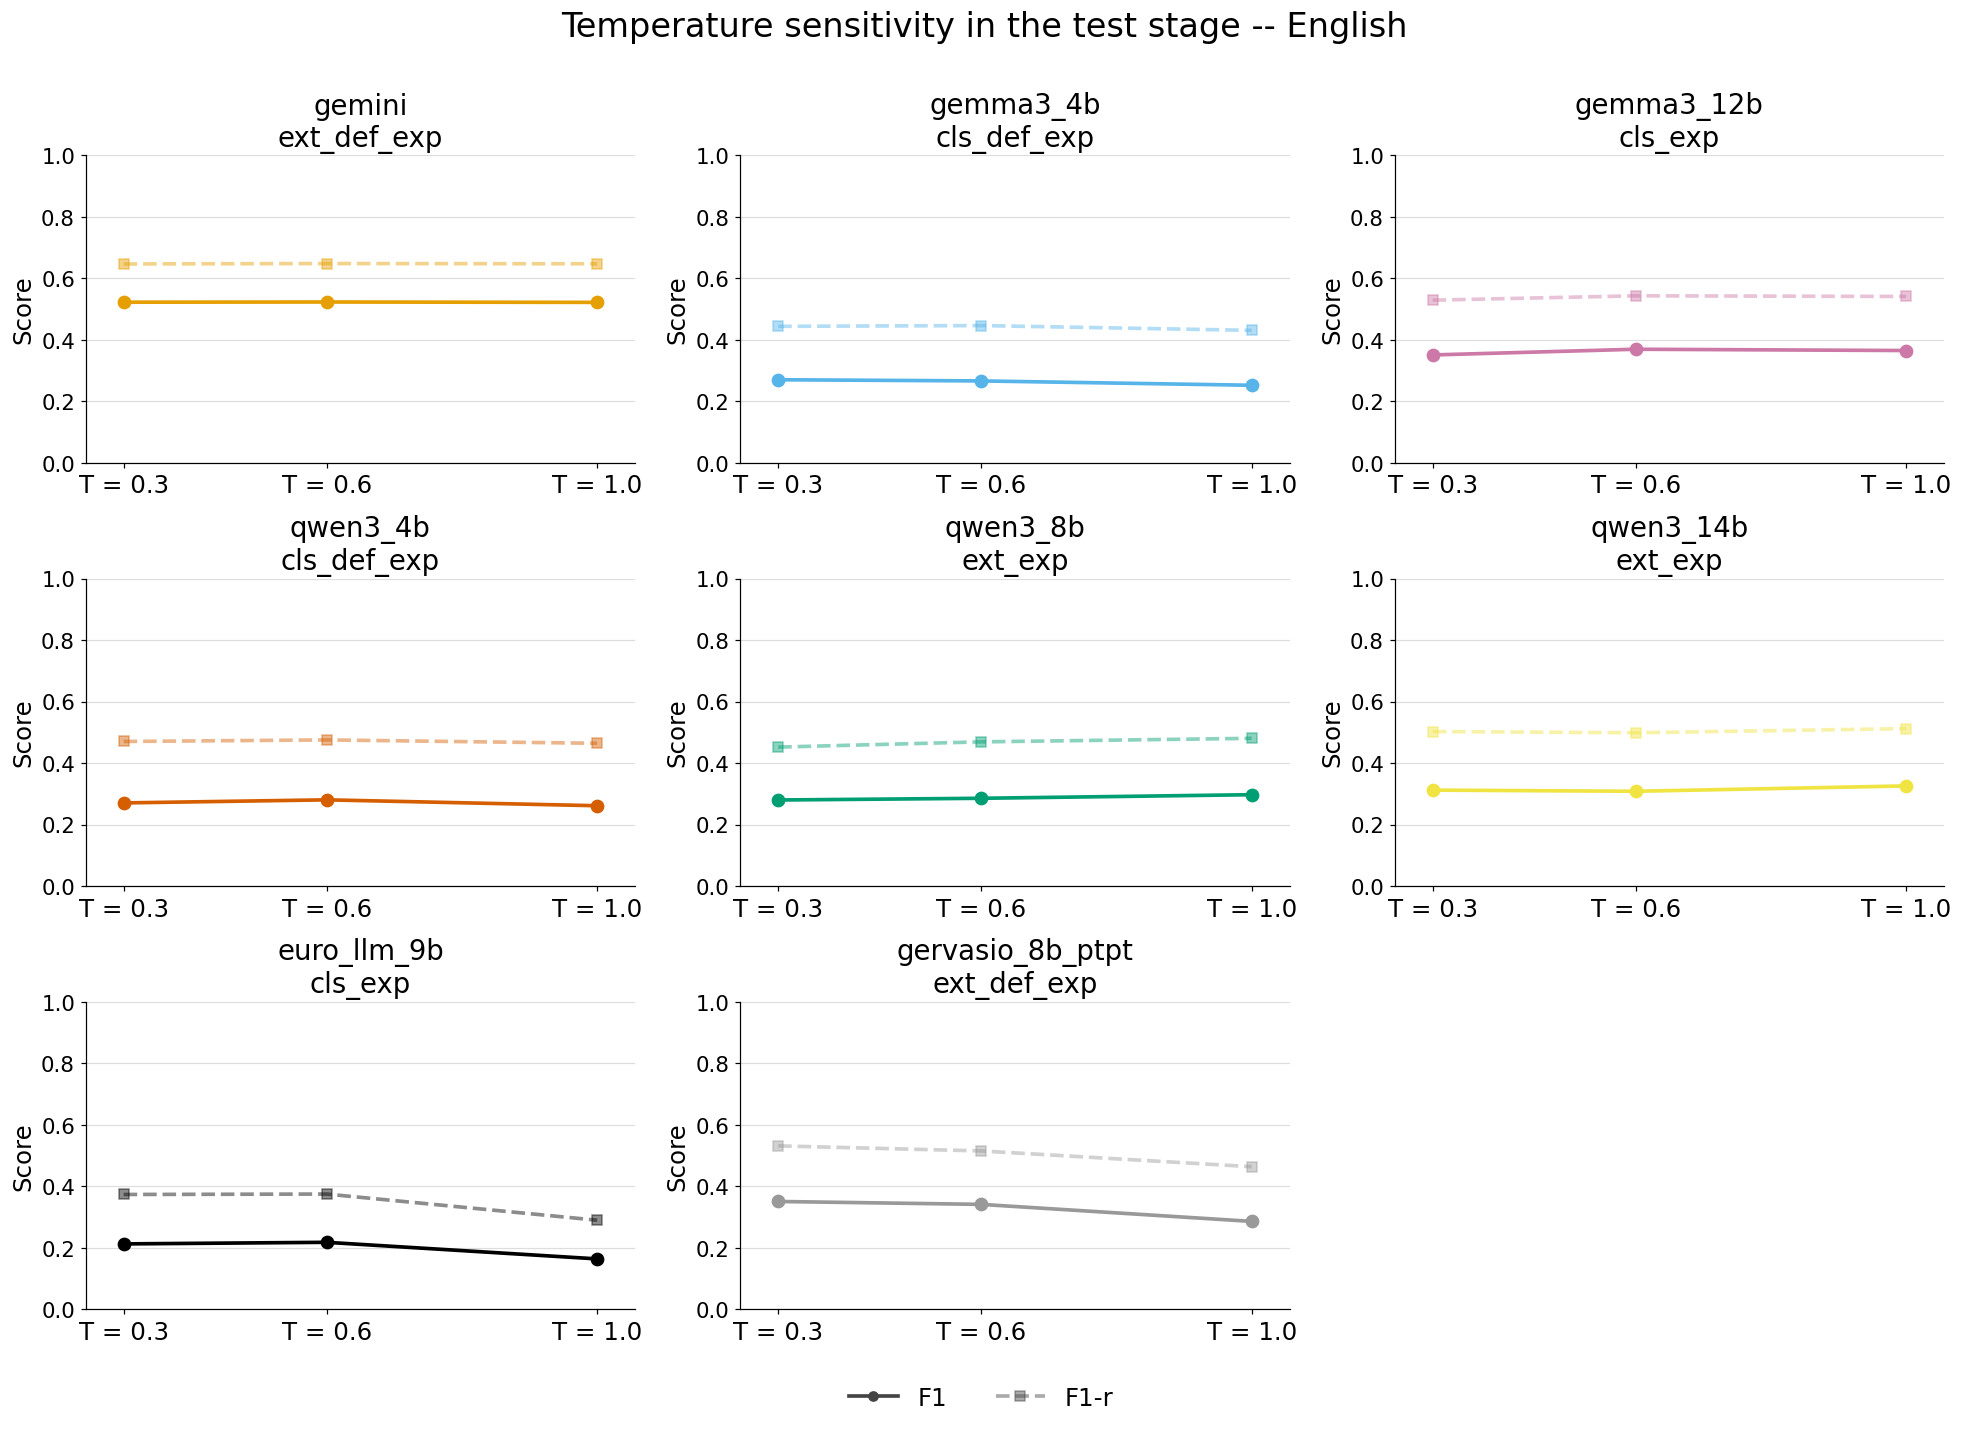

In [11]:
ABLATION_NCOLS = 3
ABLATION_MAX_ROWS = 3

# amalia is served through an API that does not expose the decoding
# temperature, so it has a single recorded point and contributes no
# temperature signal -- excluded from this figure rather than shown as a
# single-point panel.
ABLATION_EXCLUDED_MODELS = ["amalia"]


def plot_temperature_ablation(language: str):
    """A 3-column grid of per-model panels for `language`.

    Each panel plots F1 and F1-r against decoding temperature. Temperature is
    an ordered, continuous setting rather than a set of unrelated conditions,
    so the sweep is drawn as a trend line: what matters is the direction and
    steepness of each model's response, which a grouped bar chart makes the
    reader reconstruct from bar heights. The panels share an x range, so the
    slopes are directly comparable across models.
    """
    sub = ablation[
        (ablation["language"] == language) & ~ablation["model"].isin(ABLATION_EXCLUDED_MODELS)
    ]
    models = [m for m in c.MODEL_ORDER if m in set(sub["model"])][: ABLATION_MAX_ROWS * ABLATION_NCOLS]
    nrows = int(np.ceil(len(models) / ABLATION_NCOLS))
    temperatures = np.sort(sub[sub["model"].isin(models)]["temperature"].unique())
    pad = 0.08 * (temperatures[-1] - temperatures[0])

    fig, axes = plt.subplots(nrows, ABLATION_NCOLS, figsize=(6.0 * ABLATION_NCOLS, 4.4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, model in zip(axes, models):
        m = sub[sub["model"] == model].sort_values("temperature")
        color = c.MODEL_COLORS[model]
        ax.plot(m["temperature"], m["f1"], color=color, linewidth=2.4,
                marker="o", markersize=8)
        ax.plot(m["temperature"], m["f1_r"], color=color, linewidth=2.4, alpha=0.45,
                linestyle="--", marker="s", markersize=7)
        ax.set_xticks(temperatures)
        ax.set_xticklabels([f"T = {t:.1f}" for t in temperatures], fontsize=16)
        ax.set_xlim(temperatures[0] - pad, temperatures[-1] + pad)
        ax.set_ylabel("Score", fontsize=16)
        ax.set_ylim(0, 1)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_title(f"{model}\n{m['base_template'].iloc[0]}", fontsize=18)
        c.style_axis(ax)

    for ax in axes[len(models):]:
        ax.axis("off")

    legend_handles = [
        plt.Line2D([], [], color="#444444", linewidth=2.4, marker="o", label="F1"),
        plt.Line2D([], [], color="#444444", linewidth=2.4, marker="s",
                   linestyle="--", alpha=0.45, label="F1-r"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=16, frameon=False)
    fig.suptitle(f"Temperature sensitivity in the test stage -- {language.capitalize()}", fontsize=22)
    fig.tight_layout(rect=(0, 0.05, 1, 0.97))
    c.save_fig(fig, f"01_temperature_ablation_{language}", tight=False)
    plt.show()


for lang in c.LANGUAGE_ORDER:
    plot_temperature_ablation(lang)

## Selecting the best (template, temperature) configuration

`best_templates.json` above answers *which prompt template*. But every
test-stage run also fixes a decoding temperature, and encodes it in the run
name (`<template>_temp<T>_<delim>_<role>_<cot>`), so a bare template name like
`cls_def_exp` matches **no** test-stage run at all. Notebooks 02-04 therefore
need the best *(template, temperature)* pair to be able to point at a single
run per (model, language).

`_common.select_best_test_configs` resolves that in two steps per
(model, language):

1. Keep the test-stage runs whose base template is the one selected above.
   Where the test stage was never actually run with that template, fall back
   to the single template that *was* run there and flag the row as
   `test_stage_fallback` -- this affects PT/`qwen3_4b` (prompt selection
   narrowly favoured `ext_exp`, 0.278 vs 0.276, but only `cls_def_exp` was run
   at test time) and EN/`euro_llm_9b`, EN/`qwen3_4b`, EN/`qwen3_8b`.
2. Among those, take the argmax-F1 run. Where a model has both swept runs and
   an older unsuffixed one (PT/`gemini`), only the swept runs are compared, so
   temperature is the only thing varying and the older run's different
   delimiter/role/CoT settings do not leak into the choice.

**Caveat to carry into the write-up:** step 2 selects the temperature on the
test set itself. The F1 reported in notebooks 02-04 is therefore a
*best-configuration* figure -- the right number for "how well can this model
do on this task" -- but optimistic as a generalisation estimate. The sweep
above bounds how much optimism that is: within a model the 0.3-1.0 spread is
typically a few F1 points, against the ~0.20-0.45 range seen across
templates.

In [12]:
test_results = pd.concat([c.load_results("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_configs = c.select_best_test_configs(test_results, best_templates)
best_configs

[select_best_test_configs] english/euro_llm_9b: prompt-selection best template ('cls_def_exp') was never run in the test stage; falling back to the single template actually run there ('cls_exp').
[select_best_test_configs] english/gemini: prompt-selection best template ('cls_def_exp') was never run in the test stage; falling back to the single template actually run there ('ext_def_exp').
[select_best_test_configs] english/qwen3_4b: prompt-selection best template ('cls_exp') was never run in the test stage; falling back to the single template actually run there ('cls_def_exp').
[select_best_test_configs] english/qwen3_8b: prompt-selection best template ('ext_def_exp') was never run in the test stage; falling back to the single template actually run there ('ext_exp').
[select_best_test_configs] portuguese/gemini: ignoring pre-sweep run(s) ['cls_def_exp'] in favour of the 3 explicit temperature runs.
[select_best_test_configs] portuguese/qwen3_4b: prompt-selection best template ('ext_exp'

,language,model,template,base_template,temperature,f1,f1_r,n_candidates,template_source
0,english,amalia,cls_def_exp_temp0.3_nodelim_norole_nocot,cls_def_exp,0.3,0.105235,0.147683,1,prompt_selection
1,english,euro_llm_9b,cls_exp_temp0.6_nodelim_norole_nocot,cls_exp,0.6,0.218257,0.375175,3,test_stage_fallback
2,english,gemini,ext_def_exp_temp0.6_nodelim_norole_nocot,ext_def_exp,0.6,0.523115,0.648216,3,test_stage_fallback
3,english,gemma3_12b,cls_exp_temp0.6_nodelim_norole_nocot,cls_exp,0.6,0.369510,0.543279,3,prompt_selection
4,english,gemma3_4b,cls_def_exp_temp0.3_nodelim_norole_nocot,cls_def_exp,0.3,0.270296,0.444007,3,prompt_selection
5,english,gervasio_8b_ptpt,ext_def_exp_temp0.3_nodelim_norole_nocot,ext_def_exp,0.3,0.351032,0.531864,3,prompt_selection
6,english,qwen3_14b,ext_exp_temp1_nodelim_norole_nocot,ext_exp,1.0,0.325909,0.512367,3,prompt_selection
7,english,qwen3_4b,cls_def_exp_temp0.6_nodelim_norole_nocot,cls_def_exp,0.6,0.280651,0.475483,3,test_stage_fallback
8,english,qwen3_8b,ext_exp_temp1_nodelim_norole_nocot,ext_exp,1.0,0.297336,0.480679,3,test_stage_fallback
9,portuguese,amalia,cls_def_exp_temp0.3_nodelim_norole_nocot,cls_def_exp,0.3,0.169206,0.285020,1,prompt_selection


In [13]:
path = c.save_best_configs(best_configs)
print(f"Saved best (template, temperature) configurations to {path}")

Saved best (template, temperature) configurations to C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\notebooks\results\best_configs.json


## Synthesis

- Feeds **RQ1**: the `*_exp` templates (`cls_exp`, `cls_def_exp`, `ext_exp`, `ext_def_exp`) take the four highest
  median-F1 ranks out of the 8 templates, in both languages (see the heatmap and the combined
  boxplot) -- and are the argmax-F1 best template for every one of the 4 models, in both
  languages (`best_templates.json` below). Adding a worked example to the prompt is the single
  largest lever on span-extraction reliability observed here, ahead of adding a class definition
  or switching between classify (`cls_*`) and extract (`ext_*`) framing.
- Prompt sensitivity (F1 std/range across the 8 templates) is highest for `gemini` (std ~0.20,
  range ~0.45-0.51) and lowest for `qwen25_14b` and `gemma3_1b` (std ~0.05-0.08) in both
  languages -- larger/more capable does not mean less prompt-sensitive here; `qwen3_4b` sits in
  between (std ~0.08-0.09).
- `best_templates.json` holds the best (model, language) template pair -- argmax F1 only, no
  F1-r tie-break, for consistency with the heatmap.
- The test-stage temperature sweep (PT and EN) gives a secondary read on how much of each model's
  variance is prompt-*content* sensitivity (this section) vs. decoding-*temperature* sensitivity.
  Temperature moves F1 far less than template choice does: within a model the 0.3-1.0 spread is
  typically a few F1 points, against the ~0.20-0.45 range seen across templates. Direction is not
  uniform: the qwen3 models are flat or mildly *improved* at T=1.0, whereas `euro_llm_9b` and
  `gervasio_8b_ptpt` degrade clearly there (`euro_llm_9b` PT: 0.260 at T=0.3 down to 0.154 at
  T=1.0, the largest temperature effect in either language). Sweep depth is uneven (0.3/0.6/1.0
  for every model except `amalia`, which has a single recorded point in each language), so
  cross-model comparisons here are qualitative, not a controlled ablation.
- `best_configs.json` combines the two: per (model, language), the best template *and* the
  argmax-F1 temperature among the test-stage runs carrying that template. That -- not
  `best_templates.json` -- is what notebooks 02-04 filter on, since a bare template name matches
  no test-stage run. Because the temperature is picked on the test set, treat the resulting F1 as
  a best-configuration figure rather than a held-out estimate.
- `llama32_3b` is excluded throughout (see the note at the top of this notebook and
  `_common.EXCLUDED_MODELS`): its results are invalid, not just weak.
- Numeric interpretation to be condensed into `report/Chapters/Results.tex` prose in a future
  iteration (see the plan's RQ map).

## Prompt importance for the classification task (F1-classification)

Everything above scores **F1-extraction**: a prediction counts as correct when
its span matches an annotated participant, regardless of the type assigned to
it. That is the only criterion the eight templates share, since the `ext_*`
family never predicts a type at all.

The four `cls_*` templates do, so they can additionally be scored under
**F1-classification**, which requires the span *and* the type to match. A span
located correctly but typed incorrectly is counted as a false positive for the
type claimed and a false negative for the type missed, so it is penalised on
both sides rather than partially credited. Extraction and classification
therefore partition the same set of span-level outcomes and share their
denominators exactly, which is what makes `f1_ext - f1_cls` readable as the
cost of assigning a type, and guarantees `f1_cls <= f1_ext`.

This section repeats the three prompt-importance views above -- heatmap,
boxplot, dispersion -- on `f1_cls`, over `c.CLS_ONLY_PROMPT_VAR_ORDER` and in
both languages, to ask whether the prompt components that help extraction are
the same ones that help typing.

`results.csv` carries only the span-level score, so `f1_cls` is recomputed from
`detailed_results.csv`, which records the predicted and annotated type of every
tp/fp/fn row. The recomputed `f1_ext` on the same frame reproduces the
`results.csv` `f1` column exactly (asserted below), so the two scores in this
section come from one consistent pass over the data.

Location labels are coarsened first (`c.coarsen_types`: any `Pl_*` subtype ->
`Loc`), the headline view for the document-level regime -- see notebook 08 for
why.

In [14]:
# F1-extraction and F1-classification per (language, model, cls-template),
# recomputed from the per-prediction records.
CLS_TEMPLATES = c.CLS_ONLY_PROMPT_VAR_ORDER

detailed = pd.concat(
    [c.load_detailed("prompt_selection", lang) for lang in c.LANGUAGE_ORDER],
    ignore_index=True,
)
detailed = c.coarsen_types(detailed)
detailed = detailed[detailed["template"].isin(CLS_TEMPLATES)]

cls_scores = c.compute_extraction_classification_metrics(
    detailed, group_cols=["language", "model", "template"]
)
# Same model set as every other figure in this notebook.
cls_scores = cls_scores[cls_scores["model"].isin(c.MODEL_ORDER)].reset_index(drop=True)

# The recomputed extraction score must agree with the one results.csv reports,
# otherwise the two halves of this section are not measuring the same runs.
_check = cls_scores.merge(
    results[["language", "model", "template", "f1"]],
    on=["language", "model", "template"], how="inner",
)
assert (_check["f1_ext"] - _check["f1"]).abs().max() < 1e-9, "f1_ext disagrees with results.csv f1"
print(f"f1_ext reproduces results.csv f1 on all {len(_check)} runs "
      f"(max abs. difference {(_check['f1_ext'] - _check['f1']).abs().max():.2e})")

cls_scores[["language", "model", "template", "f1_ext", "f1_cls"]].assign(
    gap=lambda d: d["f1_ext"] - d["f1_cls"],
    retention=lambda d: d["f1_cls"] / d["f1_ext"],
).round(3)

f1_ext reproduces results.csv f1 on all 72 runs (max abs. difference 8.33e-17)


,language,model,template,f1_ext,f1_cls,gap,retention
0,english,amalia,cls,0.000,0.000,0.000,NaN
1,english,amalia,cls_def,0.014,0.007,0.007,0.500
2,english,amalia,cls_def_exp,0.144,0.118,0.026,0.818
3,english,amalia,cls_exp,0.080,0.068,0.012,0.852
4,english,euro_llm_9b,cls,0.015,0.015,0.000,1.000
5,english,euro_llm_9b,cls_def,0.014,0.007,0.007,0.500
6,english,euro_llm_9b,cls_def_exp,0.251,0.203,0.048,0.809
7,english,euro_llm_9b,cls_exp,0.204,0.150,0.054,0.737
8,english,gemini,cls,0.259,0.184,0.075,0.710
9,english,gemini,cls_def,0.302,0.223,0.080,0.737


### F1-classification by (model, template)

The counterpart of the F1 heatmap above, restricted to the four `cls_*`
templates and ordered so each successive column adds one prompt component
(bare -> `+def` -> `+exp` -> `+def+exp`). The colour scale is kept on the full
0-1 range so this panel can be read directly against the extraction heatmap
rather than on its own rescaled axis.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_f1_cls_heatmap.pdf


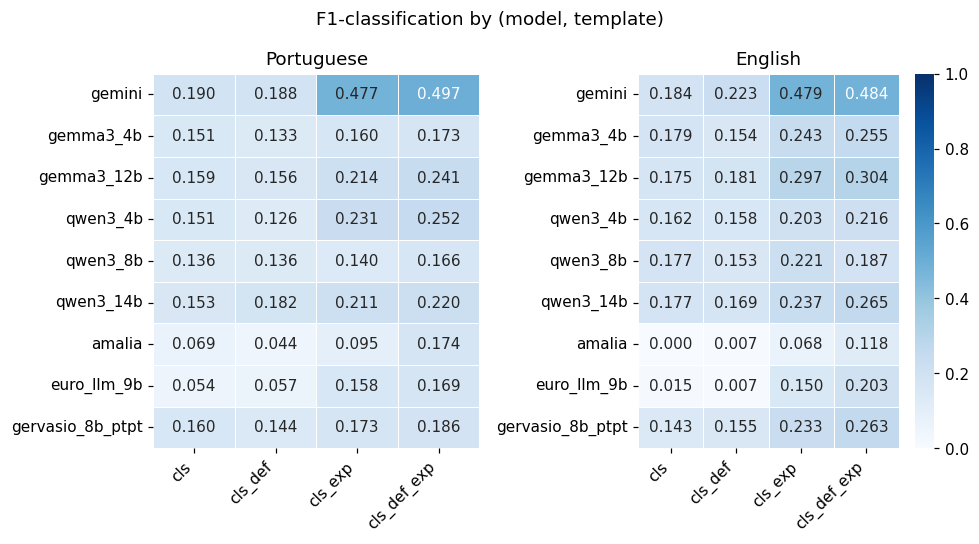

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for i, (ax, lang) in enumerate(zip(axes, c.LANGUAGE_ORDER)):
    sub = cls_scores[cls_scores["language"] == lang]
    pivot = sub.pivot(index="model", columns="template", values="f1_cls").reindex(
        index=c.MODEL_ORDER, columns=CLS_TEMPLATES
    )
    sns.heatmap(
        pivot, ax=ax, cmap=c.HEATMAP_CMAP, vmin=0, vmax=1, annot=True, fmt=".3f",
        cbar=(i == len(c.LANGUAGE_ORDER) - 1), linewidths=0.5, linecolor="white",
    )
    ax.set_title(lang.capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("F1-classification by (model, template)")
c.save_fig(fig, "01_f1_cls_heatmap")
plt.show()

### F1-classification distribution per template

One box per (template, language) over the models, pooling away the per-model
level so the template effect is isolated -- the classification counterpart of
the combined boxplot above. The axis is again the full 0-1 range.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_f1_cls_boxplot_by_template_language.pdf


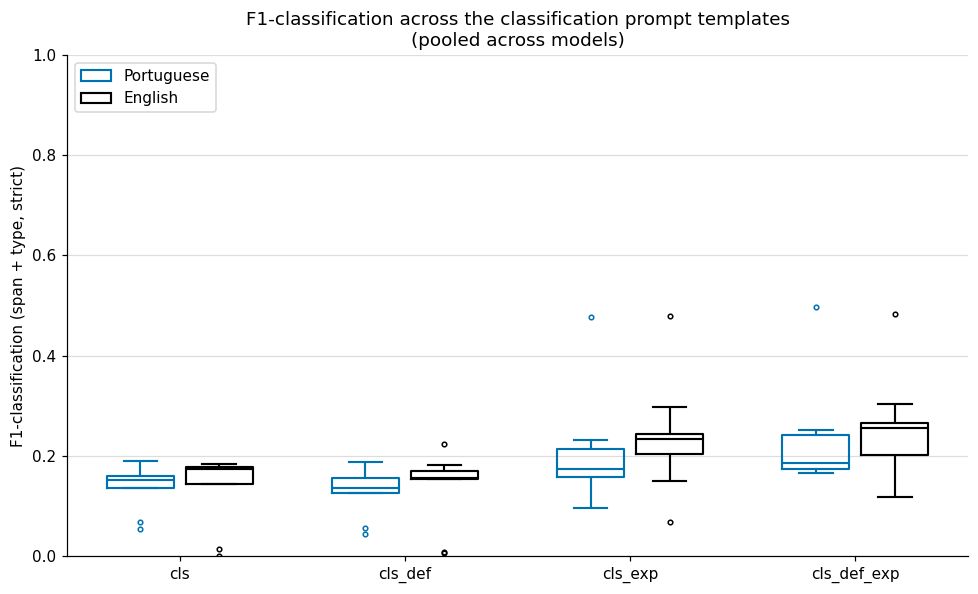

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(
    data=cls_scores, x="template", y="f1_cls", hue="language",
    order=CLS_TEMPLATES, hue_order=c.LANGUAGE_ORDER,
    palette=c.LANGUAGE_COLORS, fill=False, gap=0.15, width=0.7,
    linewidth=1.4, fliersize=3, ax=ax,
)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("F1-classification (span + type, strict)")
ax.set_title("F1-classification across the classification prompt templates\n(pooled across models)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [l.capitalize() for l in labels], title=None, loc="upper left")
c.style_axis(ax)
c.save_fig(fig, "01_f1_cls_boxplot_by_template_language")
plt.show()

### Prompt sensitivity of F1-classification

Dispersion of `f1_cls` across the templates, per (model, language) -- the
classification counterpart of the span-level dispersion bar chart above.

**These standard deviations are taken over 4 templates, not 8**, so their
magnitudes are not directly comparable to the span-level figure; only the
ranking of models between the two is. The span-level standard deviation
restricted to the same four templates is reported alongside for that reason.

In [17]:
cls_disp = (
    cls_scores.groupby(["language", "model"])
    .agg(
        std=("f1_cls", "std"),
        min=("f1_cls", "min"),
        max=("f1_cls", "max"),
        std_ext=("f1_ext", "std"),
        n_templates=("f1_cls", "size"),
    )
    .assign(range=lambda d: d["max"] - d["min"])
    .reset_index()
)
cls_disp.round(3)

,language,model,std,min,max,std_ext,n_templates,range
0,english,amalia,0.056,0.000,0.118,0.066,4,0.118
1,english,euro_llm_9b,0.098,0.007,0.203,0.124,4,0.196
2,english,gemini,0.161,0.184,0.484,0.167,4,0.300
3,english,gemma3_12b,0.071,0.175,0.304,0.087,4,0.129
4,english,gemma3_4b,0.049,0.154,0.255,0.070,4,0.100
5,english,gervasio_8b_ptpt,0.059,0.143,0.263,0.092,4,0.120
6,english,qwen3_14b,0.047,0.169,0.265,0.055,4,0.096
7,english,qwen3_4b,0.029,0.158,0.216,0.043,4,0.058
8,english,qwen3_8b,0.028,0.153,0.221,0.037,4,0.068
9,portuguese,amalia,0.057,0.044,0.174,0.070,4,0.130


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\01_f1_cls_prompt_sensitivity_dispersion.pdf


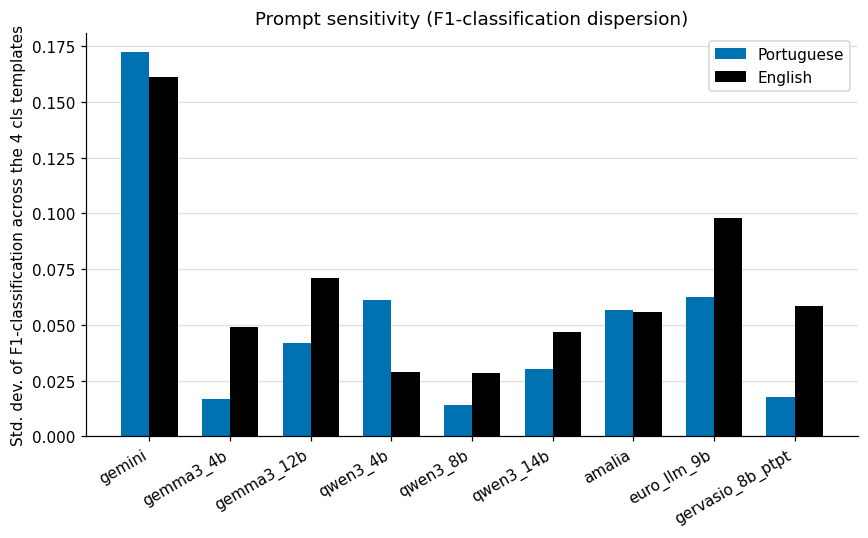

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
models = [m for m in c.MODEL_ORDER if m in set(cls_disp["model"])]
x = np.arange(len(models))
width = 0.35
for i, lang in enumerate(c.LANGUAGE_ORDER):
    sub = cls_disp[cls_disp["language"] == lang].set_index("model").reindex(models)
    ax.bar(x + (i - 0.5) * width, sub["std"].values, width=width,
           color=c.LANGUAGE_COLORS[lang], label=lang.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylabel("Std. dev. of F1-classification across the 4 cls templates")
ax.set_title("Prompt sensitivity (F1-classification dispersion)")
ax.legend()
c.style_axis(ax)
c.save_fig(fig, "01_f1_cls_prompt_sensitivity_dispersion")
plt.show()

### Reading the three views together

In [19]:
# Template-level summary: does the component that helps extraction also help
# typing? `retention` is f1_cls / f1_ext -- the share of correctly located
# participants that also carry the right type.
by_template = (
    cls_scores.groupby(["language", "template"])[["f1_ext", "f1_cls"]].median()
    .assign(gap=lambda d: d["f1_ext"] - d["f1_cls"],
            retention=lambda d: d["f1_cls"] / d["f1_ext"])
    .reset_index()
)
by_template["template"] = pd.Categorical(by_template["template"], CLS_TEMPLATES, ordered=True)
by_template.sort_values(["language", "template"]).round(3).reset_index(drop=True)

,language,template,f1_ext,f1_cls,gap,retention
0,english,cls,0.191,0.175,0.016,0.914
1,english,cls_def,0.168,0.155,0.014,0.919
2,english,cls_exp,0.260,0.233,0.027,0.895
3,english,cls_def_exp,0.292,0.255,0.037,0.872
4,portuguese,cls,0.164,0.151,0.013,0.921
5,portuguese,cls_def,0.139,0.136,0.003,0.981
6,portuguese,cls_exp,0.213,0.173,0.039,0.816
7,portuguese,cls_def_exp,0.226,0.186,0.040,0.821


### From the extracted spans alone: F1-post-ext-cls

`f1_cls` above is a global score: a participant the model never found is a
false negative for its type just as much as one it found and mistyped. That is
the right figure for the task as a whole, but it cannot say whether typing is
itself a bottleneck or is merely inheriting an extraction failure.

**F1-post-ext-cls** answers that directly by scoring only the spans the model
already located -- the span-level true positives. Extraction failures are
excluded by construction, so what is left is the typing decision on its own.

The two compose exactly. Extraction and classification share their
denominators, so `tp_cls / tp_ext` is a single factor scaling precision and
recall alike, and therefore scaling their harmonic mean:

> **F1-classification = F1-extraction x F1-post-ext-cls**

which decomposes end-to-end performance into *locating* and *typing*. The
assertion below checks this against the data rather than taking it on trust.
(It also means the `retention` column above was already this quantity, in its
micro form, unnamed.)

The micro form is what appears in that identity, but it is a poor summary on
its own: pooled over classes it coincides with accuracy, and the gold prior is
dominated by `Per`/`Org`/`Loc`, which are also the classes the models handle
well. **`f1_pec` below is therefore the macro average** (`macro_f1_pec`),
weighting all seven coarse classes equally, so the rare types the models
struggle with are not averaged away by the frequent ones they do not.

Aggregation follows the same convention as the table above: scores are computed
per (model, template), then a median is taken over models, so every model
counts once regardless of how many participants its documents contain.

In [20]:
# Typing quality over the correctly extracted spans only.
pec_scores = c.compute_post_extraction_classification_metrics(
    detailed, group_cols=["language", "model", "template"]
)
pec_scores = pec_scores[pec_scores["model"].isin(c.MODEL_ORDER)].reset_index(drop=True)

scores = cls_scores.merge(pec_scores, on=["language", "model", "template"], how="inner")

# F1-classification must factor exactly into extraction x post-extraction typing.
_dev = (scores["f1_cls"] - scores["f1_ext"] * scores["micro_f1_pec"]).abs().max()
assert _dev < 1e-9, f"decomposition identity does not hold (max deviation {_dev:.2e})"
print(f"f1_cls = f1_ext x micro_f1_pec holds on all {len(scores)} runs "
      f"(max abs. deviation {_dev:.2e})")
print(f"span tps scored: {int(scores['n_spans_pec'].sum())}, "
      f"of which {int(scores['untyped_pec'].sum())} carry no parsable predicted type")

scores[["language", "model", "template", "n_spans_pec",
        "tp_pec", "fp_pec", "micro_f1_pec", "macro_f1_pec"]].round(3)

f1_cls = f1_ext x micro_f1_pec holds on all 71 runs (max abs. deviation 1.11e-16)
span tps scored: 6839, of which 0 carry no parsable predicted type


,language,model,template,n_spans_pec,tp_pec,fp_pec,micro_f1_pec,macro_f1_pec
0,english,amalia,cls_def,4,2,2,0.500,0.200
1,english,amalia,cls_def_exp,55,45,10,0.818,0.592
2,english,amalia,cls_exp,27,23,4,0.852,0.715
3,english,euro_llm_9b,cls,4,4,0,1.000,1.000
4,english,euro_llm_9b,cls_def,4,2,2,0.500,0.333
5,english,euro_llm_9b,cls_def_exp,110,89,21,0.809,0.492
6,english,euro_llm_9b,cls_exp,99,73,26,0.737,0.467
7,english,gemini,cls,124,88,36,0.710,0.641
8,english,gemini,cls_def,133,98,35,0.737,0.644
9,english,gemini,cls_def_exp,306,260,46,0.850,0.630


In [21]:
# Locating, typing, and the two combined -- one row per (language, template).
decomposition = (
    scores.groupby(["language", "template"])[["f1_ext", "f1_cls", "macro_f1_pec"]]
    .median()
    .rename(columns={"macro_f1_pec": "f1_pec"})
    .reset_index()
)
decomposition["template"] = pd.Categorical(
    decomposition["template"], CLS_TEMPLATES, ordered=True
)
decomposition = decomposition.sort_values(["language", "template"]).reset_index(drop=True)
decomposition[["language", "template", "f1_ext", "f1_cls", "f1_pec"]].round(3)

,language,template,f1_ext,f1_cls,f1_pec
0,english,cls,0.192,0.176,0.666
1,english,cls_def,0.168,0.155,0.644
2,english,cls_exp,0.260,0.233,0.586
3,english,cls_def_exp,0.292,0.255,0.588
4,portuguese,cls,0.164,0.151,0.619
5,portuguese,cls_def,0.139,0.136,0.796
6,portuguese,cls_exp,0.213,0.173,0.530
7,portuguese,cls_def_exp,0.226,0.186,0.600
